In [3]:
import os
import jax
import jax.numpy as jnp
import numpy as np
import optax
import wandb
import torch
from torch.utils.data import DataLoader, TensorDataset

from tn4ml.models.smpo import SMPO_initialize
from tn4ml.initializers import gramschmidt
from tn4ml.embeddings import TrigonometricEmbedding, PolynomialEmbedding, embed
from tn4ml.util import TrainingType, EarlyStopping
from tn4ml.models import Model
import quimb.tensor as qtn
from tn4ml.metrics import *

jax.config.update("jax_enable_x64", True)

# -------------------------------
# Data Preparation
# -------------------------------

import utils.dataloader as d

epochs = 40
learning_rate = 1e-3
batch_size = 5000
path = "/fs/ddn/sdf/group/atlas/d/lapereir/AD/"


# load training data
dataloader = d.load_data(path + "background_for_training.h5", batch_size=batch_size, shuffle=True, norm=True) # for some reason with norm=True the loss is NaN.. this does not seem to be the case without normalisation
print("# batches ", len(dataloader))
print(next(iter(dataloader)).shape)

L = next(iter(dataloader)).shape[-1] # L is the # of training variables
print("L = ", L)

# -------------------------------
# Configuration and Initialization
# -------------------------------

# Model hyperparameters
key = jax.random.PRNGKey(42)
bond_dim = 20
phys_dim = (4, 4)
initializer = gramschmidt('normal', 1e-1)
shape_method = 'noteven'
spacing = 8
add_identity = True
boundary = 'obc'

# -------------------------------
# Model Initialization
# -------------------------------

smpo = SMPO_initialize(
    L=L,
    initializer=initializer,
    key=key,
    shape_method=shape_method,
    spacing=spacing,
    bond_dim=bond_dim,
    phys_dim=phys_dim,
    cyclic=False,
    compress=True,
    add_identity=add_identity,
    boundary=boundary
)

# Use quimb's packing/unpacking trick
arrays, skeleton = qtn.pack(smpo)

# Create an empty Model
model = Model()

# Rebuild the internal tensor structure
model_tn = qtn.unpack(arrays, skeleton)

# Now overwrite internal quimb TensorNetwork internals
model.__dict__.update(model_tn.__dict__)

model.L = len(model.tensors)
model.apply = smpo.apply

# Model configuration

alpha = 0.4
def loss_combined(*args, **kwargs):
    error = LogQuadNorm
    reg = LogReLUFrobNorm
    return CombinedLoss(*args, **kwargs, error=error, reg=lambda P: alpha*reg(P))


optimizer = optax.adam
strategy = 'global'
loss = loss_combined
train_type = TrainingType.UNSUPERVISED
embedding = PolynomialEmbedding(degree=3, n=1, include_bias=True)
learning_rate = 1e-4
earlystop = EarlyStopping(min_delta=0, patience=5, monitor='loss', mode='min')

model.configure(optimizer=optimizer, strategy=strategy, loss=loss, train_type=train_type, learning_rate=learning_rate)
model.device = 'gpu'


Normalising inputs with norm_parameters.npz
# batches  800
torch.Size([5000, 56])
L =  56


In [1]:
from utils.dataset import var_dict
print(len(var_dict.keys()))

56


In [14]:
for i in range(len(dataloader)):
    if jnp.any(jnp.isnan(jnp.array(next(iter(dataloader))))): print("NaN in batch ", i)

In [11]:
#import copy

def loss_fn(data, targets, *params):
    tn = smpo.copy(deep=True)  # use SMPO, not Model

    for t, p in zip(tn.tensors, params):
        t.modify(data=p)

    tn_i = embed(data, embedding)
    return model.loss(tn, tn_i)

loss_func = jax.jit(jax.vmap(loss_fn, in_axes=[0, None] + [None]*model.L), backend=model.device)
grads_func = jax.jit(jax.vmap(jax.grad(loss_fn, argnums=range(2, 2+model.L)), in_axes=[0, None] + [None]*model.L), backend=model.device)

params = model.arrays
model.step, model.opt_state = model.create_train_step(params=params, loss_func=loss_func, grads_func=grads_func)


In [12]:
from tqdm import tqdm
import time

history = {"learning_rate": learning_rate, 'loss': [], 'epoch_time': [], 'unfinished': True}

os.environ["WANDB_NOTEBOOK_NAME"] = "training.ipynb"

wandb.init(project="tn4ml_unsupervised", name="holi_20k_batch_1e-2_lr")

#wandb.monitor()  # force monitoring

for epoch in range(epochs):
    start_time = time.time()
    epoch_loss = 0
    for i, batch in enumerate(tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")):
        batch = jax.numpy.array(batch, dtype=jnp.float64) # try 64?
        #if i %10 ==0: print("batch ", i, " data shape ", batch.shape)
        params = model.arrays
        params, model.opt_state, loss = model.step(params, model.opt_state, data=batch)
        model.update_tensors(params)
        epoch_loss += loss
        wandb.log({"loss": loss})  # optional per-batch logging

    end_time = time.time()
    avg_loss = epoch_loss / len(dataloader)
    history['loss'].append(avg_loss)
    history['epoch_time'].append(end_time - start_time)

    wandb.log({
        "epoch": epoch,
        "loss": avg_loss,
        "epoch_time": end_time - start_time
    })
    
    print(f"[Epoch {epoch}] Loss: {avg_loss:.6f} | Time: {end_time - start_time:.2f}s")
    history['unfinished'] = False  # training completed successfully

wandb.finish()
print("Final history:", history)


wandb: Currently logged in as: lapereir (atlas-gnn-btag) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 1/40: 100%|██████████| 800/800 [02:51<00:00,  4.65it/s]


[Epoch 0] Loss: nan | Time: 171.92s


Epoch 2/40: 100%|██████████| 800/800 [02:34<00:00,  5.17it/s]


[Epoch 1] Loss: nan | Time: 154.79s


...

[Epoch 26] Loss: nan | Time: 154.74s


Epoch 28/40: 100%|██████████| 800/800 [02:34<00:00,  5.18it/s]


[Epoch 27] Loss: nan | Time: 154.35s


Epoch 29/40:  30%|███       | 244/800 [00:47<01:48,  5.14it/s]


KeyboardInterrupt: 

In [ ]:
def summarize_tn4ml_model(model):
    tensors = model.tensors

    print(f"Model class: {type(model).__name__}")
    print(f"Number of tensors (sites): {len(tensors)}")

    total_params = 0
    for i, tensor in enumerate(tensors):
        shape = tensor.shape
        numel = int(np.prod(shape))
        total_params += numel
        print(f"  Tensor {i:2d}: shape={shape}, num_elements={numel}")

    print(f"\nTotal number of parameters: {total_params:,}")
    print(f"Estimated memory (float64): {total_params * 8 / 1024**2:.2f} MB")

summarize_tn4ml_model(model)


In [ ]:
from tn4ml.eval import *

plot_loss(history, validation=False, figsize=(8, 6))

In [21]:
import copy
import quimb as qu

def save_model_clean(model, path):
    # Deepcopy the model to avoid modifying the live one
    model_copy = copy.deepcopy(model)

    # Remove known unpickleable attributes
    bad_attrs = [
        "opt_state", "optimizer", "step",
        "loss_func", "grads_func", "cache",
        "strategy", "loss", "train_type"
    ]

    for attr in bad_attrs:
        if hasattr(model_copy, attr):
            try:
                delattr(model_copy, attr)
            except Exception as e:
                print(f"Warning: could not delete {attr} - {e}")

    # Save using Quimb
    qu.save_to_disk(model_copy, path)

save_model_clean(model, "model_clean.pkl")


In [22]:
def evaluate_model(model, dataloader, loss_func, embedding, verbose=True):
    #total_loss = 0.0
    #total_samples = 0
    all_scores = []

    for batch in tqdm(dataloader, desc="Evaluating", disable=not verbose):
        batch = jax.numpy.array(batch, dtype=jnp.float64)
        params = model.arrays

        scores = loss_func(batch, None, *params)
        
        scores = jax.device_get(scores)
        all_scores.append(scores)

        # Compute mean loss
        #loss = loss_func(tn, embedded)
        #total_loss += loss.item() * batch.shape[0]
        #total_samples += batch.shape[0]

    return np.concatenate(all_scores)#, total_loss / total_samples


In [23]:
#saved_model = qu.load_from_disk("model_clean.pkl")
#model = saved_model


In [24]:
a4l = d.load_data(path + "Ato4l_lepFilter_13TeV.h5", batch_size=batch_size, shuffle=True)
lq = d.load_data(path + "leptoquark_LOWMASS_lepFilter_13TeV.h5", batch_size=batch_size, shuffle=True)
htnu = d.load_data(path + "hChToTauNu_13TeV_PU20.h5", batch_size=batch_size, shuffle=True)
htt = d.load_data(path + "hToTauTau_13TeV_PU20.h5", batch_size=batch_size, shuffle=True)

In [25]:

bkg_score = evaluate_model(model, dataloader, loss_func, embedding, verbose=True)
a4l_score = evaluate_model(model, a4l, loss_func, embedding, verbose=True)
lq_score = evaluate_model(model, lq, loss_func, embedding, verbose=True)
htnu_score = evaluate_model(model, htnu, loss_func, embedding, verbose=True)
htt_score  = evaluate_model(model, htt, loss_func, embedding, verbose=True)

Evaluating: 100%|██████████| 139/139 [00:12<00:00, 10.87it/s]


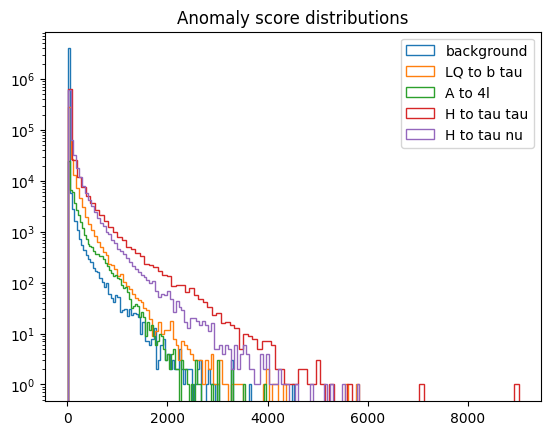

In [26]:
plt.figure()
plt.yscale('log')
plt.hist(bkg_score, bins=100, histtype='step', label='background')
plt.hist(lq_score, bins=100, histtype='step', label='LQ to b tau')
plt.hist(a4l_score, bins=100, histtype='step', label='A to 4l')
plt.hist(htt_score, bins=100, histtype='step', label='H to tau tau')
plt.hist(htnu_score, bins=100, histtype='step', label='H to tau nu')
plt.title('Anomaly score distributions')
plt.legend()
# plt.text(0.5, -0.1, f'AUC Value: {auc_value}', ha='center', transform=plt.gca().transAxes)
plt.legend()
plt.show()



In [27]:
fpr_lq, tpr_lq = get_roc_curve_data(bkg_score, lq_score, anomaly_det=True)
auc_lq = auc(fpr_lq, tpr_lq)
fpr_a4l, tpr_a4l = get_roc_curve_data(bkg_score, a4l_score, anomaly_det=True)
auc_a4l = auc(fpr_a4l, tpr_a4l)
fpr_htt, tpr_htt = get_roc_curve_data(bkg_score, htt_score, anomaly_det=True)
auc_htt = auc(fpr_htt, tpr_htt)
fpr_htnu, tpr_htnu = get_roc_curve_data(bkg_score, htnu_score, anomaly_det=True)
auc_htnu = auc(fpr_htnu, tpr_htnu)


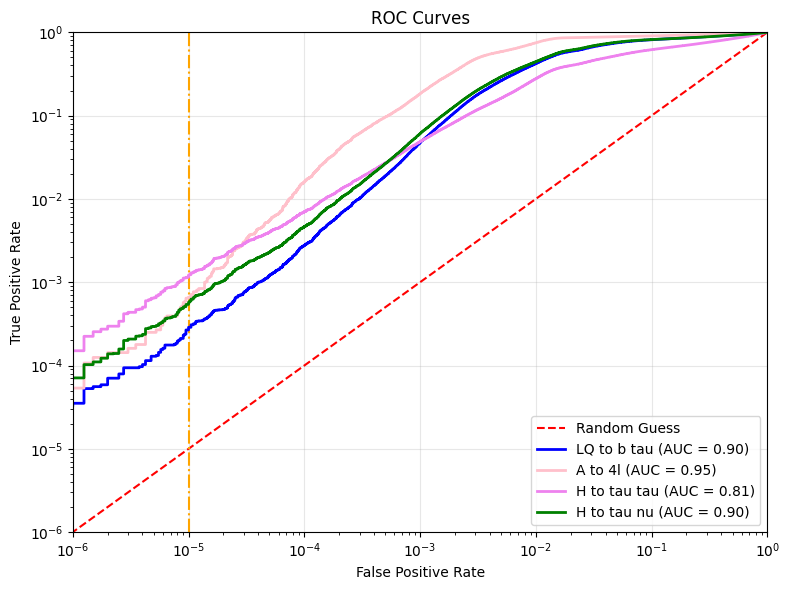

In [28]:
# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.xscale('log')
plt.yscale('log')
plt.plot([0, 1], [0, 1], color="red", linestyle="--", label="Random Guess")
plt.plot([1e-5, 1e-5], [1e-6, 1], color="orange", linestyle="-.")
plt.plot(fpr_lq, tpr_lq, color="blue", lw=2, label=f"LQ to b tau (AUC = {auc_lq:.2f})")
plt.plot(fpr_a4l, tpr_a4l, color="pink", lw=2, label=f"A to 4l (AUC = {auc_a4l:.2f})")
plt.plot(fpr_htt, tpr_htt, color="violet", lw=2, label=f"H to tau tau (AUC = {auc_htt:.2f})")
plt.plot(fpr_htnu, tpr_htnu, color="green", lw=2, label=f"H to tau nu (AUC = {auc_htnu:.2f})")
plt.xlim([1e-6, 1.0])
plt.ylim([1e-6, 1.0])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

